In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px

In [ ]:
folder_path='/content/drive/MyDrive/DAP505_Data (1)/Power Query Project/Sales Orders'

In [ ]:
for fill in os.listdir(folder_path):
  print((pd.read_csv(folder_path+'/'+fill)))

                                     Sales Report 2016
0    Order ID;Order Date;Shipping Date;Ship Mode;Cu...
1    CA-2016-152156;8/11/2016;11/11/2016;Second Cla...
2    CA-2016-152156;8/11/2016;11/11/2016;Second Cla...
3    CA-2016-138688;12/6/2016;16/6/2016;Second Clas...
4    CA-2016-161389;5/12/2016;10/12/2016;Standard C...
..                                                 ...
285  CA-2016-144939;3/10/2016;8/10/2016;Standard Cl...
286  CA-2016-110023;9/9/2016;11/9/2016;First Class;...
287  CA-2016-105585;26/8/2016;27/8/2016;First Class...
288  CA-2016-105585;26/8/2016;27/8/2016;First Class...
289  CA-2016-155488;13/11/2016;17/11/2016;Standard ...

[290 rows x 1 columns]
                                             2014 Data
0    Order ID;Order Date;Shipping Date;Ship Mode;Cu...
1    CA-2014-115812;9/6/2014;14/6/2014;Standard Cla...
2    CA-2014-115812;9/6/2014;14/6/2014;Standard Cla...
3    CA-2014-115812;9/6/2014;14/6/2014;Standard Cla...
4    CA-2014-115812;9/6/2014;14/6/2014;St

In [ ]:
dfs = []

for fill in os.listdir(folder_path):
  path = folder_path + '/' + fill

  df = pd.read_csv(path)

  df = df[df.columns[0]].str.split(';', expand = True)

  df.columns = df.loc[0]

  df = df.drop(0)
  dfs.append(df)
sales = pd.concat(dfs, ignore_index = True)
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Order ID             1007 non-null   object
 1   Order Date           1007 non-null   object
 2   Shipping Date        1007 non-null   object
 3   Ship Mode            1007 non-null   object
 4   Customer ID          1007 non-null   object
 5   Product ID           1007 non-null   object
 6   Quantity             1007 non-null   object
 7   Purchasing Price     1007 non-null   object
 8   Planned Sales Price  1007 non-null   object
 9   Discount             1007 non-null   object
dtypes: object(10)
memory usage: 78.8+ KB


In [ ]:
sales.head(5)

,Order ID,Order Date,Shipping Date,Ship Mode,Customer ID,Product ID,Quantity,Purchasing Price,Planned Sales Price,Discount
0,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,FUR-BO-10001798,2,157.17599999999999,261.95999999999998,0
1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,FUR-CH-10000454,3,402.56700000000001,731.93999999999994,0.1
2,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,OFF-LA-10000240,2,8.7719999999999985,14.62,0.05
3,CA-2016-161389,5/12/2016,10/12/2016,Standard Class,IM-15070,OFF-BI-10003656,3,203.98800000000003,407.97600000000006,0.06
4,CA-2016-137330,9/12/2016,13/12/2016,Standard Class,KB-16585,OFF-AR-10000246,7,10.702999999999999,19.459999999999997,0.06


In [ ]:
sales['Quantity'] = sales['Quantity'].astype(int)
sales[['Purchasing Price', 'Planned Sales Price', 'Discount']] = sales[['Purchasing Price', 'Planned Sales Price', 'Discount']].astype(float)
sales['Order Date'] = pd.to_datetime(sales['Order Date'], format = "%d/%m/%Y")
sales['Shipping Date'] = pd.to_datetime(sales['Shipping Date'], format = "%d/%m/%Y")
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order ID             1007 non-null   object        
 1   Order Date           1007 non-null   datetime64[ns]
 2   Shipping Date        1007 non-null   datetime64[ns]
 3   Ship Mode            1007 non-null   object        
 4   Customer ID          1007 non-null   object        
 5   Product ID           1007 non-null   object        
 6   Quantity             1007 non-null   int64         
 7   Purchasing Price     1007 non-null   float64       
 8   Planned Sales Price  1007 non-null   float64       
 9   Discount             1007 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(4)
memory usage: 78.8+ KB


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order ID             1007 non-null   object        
 1   Order Date           1007 non-null   datetime64[ns]
 2   Shipping Date        1007 non-null   datetime64[ns]
 3   Ship Mode            1007 non-null   object        
 4   Customer ID          1007 non-null   object        
 5   Product ID           1007 non-null   object        
 6   Quantity             1007 non-null   int64         
 7   Purchasing Price     1007 non-null   float64       
 8   Planned Sales Price  1007 non-null   float64       
 9   Discount             1007 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(4)
memory usage: 78.8+ KB


In [ ]:
# ##### example
# def split_column(x,d):
#   return x.split(d)
# a="CA-2016-152156"
# int(split_column(a,'-')[-1])

In [ ]:
def split_column(n,delm):
  return n.split(delm)
sales['Product ID 22'] = sales['Product ID'].apply(lambda x: int(split_column(x, '-')[2]))
sales['Customer ID 22'] = sales['Customer ID'].apply(lambda x: int(split_column(x, '-')[1]))
sales.drop(['Product ID', 'Customer ID'], axis = 1, inplace = True)
sales.head(5)

,Order ID,Order Date,Shipping Date,Ship Mode,Quantity,Purchasing Price,Planned Sales Price,Discount,Product ID 22,Customer ID 22
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,2,157.176,261.960,0.00,10001798,12520
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,3,402.567,731.940,0.10,10000454,12520
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,2,8.772,14.620,0.05,10000240,13045
3,CA-2016-161389,2016-12-05,2016-12-10,Standard Class,3,203.988,407.976,0.06,10003656,15070
4,CA-2016-137330,2016-12-09,2016-12-13,Standard Class,7,10.703,19.460,0.06,10000246,16585


In [ ]:
sales.rename(columns={'Product ID 22': 'Product ID', 'Customer ID 22': 'Customer ID'},inplace=True)
sales.head(5)

,Order ID,Order Date,Shipping Date,Ship Mode,Quantity,Purchasing Price,Planned Sales Price,Discount,Product ID,Customer ID
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,2,157.176,261.960,0.00,10001798,12520
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,3,402.567,731.940,0.10,10000454,12520
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,2,8.772,14.620,0.05,10000240,13045
3,CA-2016-161389,2016-12-05,2016-12-10,Standard Class,3,203.988,407.976,0.06,10003656,15070
4,CA-2016-137330,2016-12-09,2016-12-13,Standard Class,7,10.703,19.460,0.06,10000246,16585


In [ ]:
customer_path='/content/drive/MyDrive/DAP505_Data (1)/Power Query Project/Customer Data.xlsx'
customer = pd.read_excel(customer_path)
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer ID     358 non-null    float64
 1   Customer Name   356 non-null    object 
 2   Client Segment  356 non-null    object 
 3   Country         354 non-null    object 
 4   State           358 non-null    object 
 5   Postal Code     358 non-null    float64
 6   Region          358 non-null    object 
dtypes: float64(2), object(5)
memory usage: 20.1+ KB


In [ ]:
customer.head(5)

,Customer ID,Customer Name,Client Segment,Country,State,Postal Code,Region
0,12520.0,Claire Gute,Consumer,USA,Kentucky,42420.0,South
1,13045.0,Darrin Van Huff,Corporate,Egypt,Alex,90036.0,West
2,20335.0,Sean O'Donnell,Consumer,NaN,Alex,33311.0,South
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
customer=customer.dropna(how='all')
customer[['Customer ID','Postal Code']]=customer[['Customer ID','Postal Code']].astype(int)
customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 358 entries, 0 to 365
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     358 non-null    int64 
 1   Customer Name   356 non-null    object
 2   Client Segment  356 non-null    object
 3   Country         354 non-null    object
 4   State           358 non-null    object
 5   Postal Code     358 non-null    int64 
 6   Region          358 non-null    object
dtypes: int64(2), object(5)
memory usage: 22.4+ KB


In [ ]:
len(customer['State'].unique())
#len(customer['Country'].unique())
#State

39

In [ ]:
stat=customer[['Country','State']]
stat=stat.dropna()
stat['Country'].replace('United States','USA',inplace=True)
stat=stat.drop_duplicates(subset=['State'])
stat['State'].unique()

/tmp/ipython-input-2211099651.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stat['Country'].replace('United States','USA',inplace=True)


array(['Kentucky', 'Alex', 'Pennsylvania', 'Utah', 'Cairo', 'Texas',
       'Illinois', 'Tanta', 'Minnesota', 'Michigan', 'Delaware',
       'Indiana', 'New York', 'California', 'Arizona', 'Virginia',
       'Tennessee', 'Alabama', 'North Carolina', 'Oregon', 'Colorado',
       'Iowa', 'Ohio', 'Washington', 'Missouri', 'Wisconsin', 'Oklahoma',
       'New Mexico', 'Louisiana', 'Connecticut', 'New Jersey', 'Florida',
       'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Maryland'], dtype=object)

In [ ]:
len(stat['State'].unique())

39

In [ ]:
customer=pd.merge(customer,stat,on='State',how='left')
customer.drop(['Country_x'],axis=1,inplace=True)
customer = customer.rename({'Country_y' : 'Country'}, axis =1)
#customer.info()
customer.head(5)

,Customer ID,Customer Name,Client Segment,State,Postal Code,Region,Country
0,12520,Claire Gute,Consumer,Kentucky,42420,South,USA
1,13045,Darrin Van Huff,Corporate,Alex,90036,West,Egypt
2,20335,Sean O'Donnell,Consumer,Alex,33311,South,Egypt
3,20065,Sandra Flanagan,Consumer,Pennsylvania,19140,East,USA
4,13870,Emily Burns,Consumer,Utah,84057,West,USA


In [ ]:
product_path='/content/drive/MyDrive/DAP505_Data (1)/Power Query Project/Products.xlsx'
product=pd.read_excel(product_path)
product.info()
product.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product ID        710 non-null    int64 
 1   Product Category  710 non-null    object
 2   Sub-Category      710 non-null    object
 3   Product Name      710 non-null    object
dtypes: int64(1), object(3)
memory usage: 22.3+ KB


,Product ID,Product Category,Sub-Category,Product Name
0,10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System


In [ ]:
final=pd.merge(sales,customer,on='Customer ID',how='left')
final_df=pd.merge(final,product,on='Product ID',how='left')
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order ID             1007 non-null   object        
 1   Order Date           1007 non-null   datetime64[ns]
 2   Shipping Date        1007 non-null   datetime64[ns]
 3   Ship Mode            1007 non-null   object        
 4   Quantity             1007 non-null   int64         
 5   Purchasing Price     1007 non-null   float64       
 6   Planned Sales Price  1007 non-null   float64       
 7   Discount             1007 non-null   float64       
 8   Product ID           1007 non-null   int64         
 9   Customer ID          1007 non-null   int64         
 10  Customer Name        967 non-null    object        
 11  Client Segment       967 non-null    object        
 12  State                980 non-null    object        
 13  Postal Code          980 non-null

In [ ]:
final_df.head(5)

,Order ID,Order Date,Shipping Date,Ship Mode,Quantity,Purchasing Price,Planned Sales Price,Discount,Product ID,Customer ID,Customer Name,Client Segment,State,Postal Code,Region,Country,Product Category,Sub-Category,Product Name
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,2,157.176,261.960,0.00,10001798,12520,Claire Gute,Consumer,Kentucky,42420.0,South,USA,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,3,402.567,731.940,0.10,10000454,12520,Claire Gute,Consumer,Kentucky,42420.0,South,USA,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,2,8.772,14.620,0.05,10000240,13045,Darrin Van Huff,Corporate,Alex,90036.0,West,Egypt,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,CA-2016-161389,2016-12-05,2016-12-10,Standard Class,3,203.988,407.976,0.06,10003656,15070,NaN,NaN,NaN,NaN,NaN,NaN,Office Supplies,Binders,Fellowes PB200 Plastic Comb Binding Machine
4,CA-2016-137330,2016-12-09,2016-12-13,Standard Class,7,10.703,19.460,0.06,10000246,16585,NaN,NaN,NaN,NaN,NaN,NaN,Office Supplies,Art,Newell 318


In [ ]:
# calculat Expected profit
final_df['Expected profit']=final_df['Planned Sales Price']-final_df['Purchasing Price']
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order ID             1007 non-null   object        
 1   Order Date           1007 non-null   datetime64[ns]
 2   Shipping Date        1007 non-null   datetime64[ns]
 3   Ship Mode            1007 non-null   object        
 4   Quantity             1007 non-null   int64         
 5   Purchasing Price     1007 non-null   float64       
 6   Planned Sales Price  1007 non-null   float64       
 7   Discount             1007 non-null   float64       
 8   Product ID           1007 non-null   int64         
 9   Customer ID          1007 non-null   int64         
 10  Customer Name        967 non-null    object        
 11  Client Segment       967 non-null    object        
 12  State                980 non-null    object        
 13  Postal Code          980 non-null

In [ ]:
# calculat Adjusted_Profit after discount
Adjusted_Profit = np.where(
    final_df['Discount'] > 0,
    final_df['Planned Sales Price'] * (1-final_df['Discount']),
    final_df['Planned Sales Price']
)
#calculat Total profit
Total_profit=final_df['Planned Sales Price'].sum()-Adjusted_Profit.sum()

#Profit rate
Profit_rate=Total_profit/final_df['Purchasing Price'].sum()
Profit_rate

np.float64(0.10416361531988515)

In [ ]:
final_df['Product Category'].value_counts()

,count
Product Category,
Office Supplies,622
Technology,194
Furniture,191


<Axes: xlabel='Product Category'>

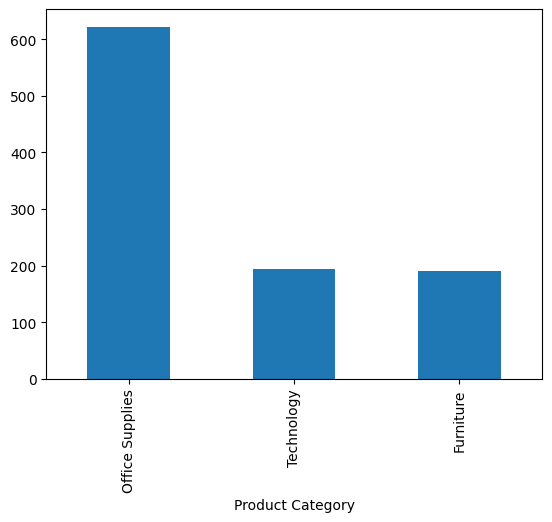

In [ ]:
#len(final_df['Product Category'].unique())
#final_df['Product Category'].value_counts()
a=final_df['Product Category'].value_counts()
a.plot(kind='bar')

In [ ]:
#final_df['Sub-Category'].value_counts()
final_df.groupby(['Product Category','Sub-Category']).size()
#final_df.groupby(['Product Category','Sub-Category']).size().reset_index(name='Count')

Product Category  Sub-Category
Furniture         Bookcases        18
                  Chairs           53
                  Furnishings      85
                  Tables           35
Office Supplies   Appliances       40
                  Art              88
                  Binders         152
                  Envelopes        33
                  Fasteners        24
                  Labels           38
                  Paper           131
                  Storage          95
                  Supplies         21
Technology        Accessories      87
                  Copiers           7
                  Machines         12
                  Phones           88
dtype: int64

In [ ]:
# subcat_counts = final_df['Sub-Category'].value_counts()

# # Plot pie chart
# plt.figure(figsize=(8, 8))
# plt.pie(
#     subcat_counts.values,           # numerical values (counts)
#     labels=subcat_counts.index,     # labels (sub-category names)
#     autopct='%1.1f%%',              # show percentage on chart
#     startangle=90                   # optional: rotate pie
# )
# plt.title("Distribution of Sub-Categories")
# plt.tight_layout()
# plt.show()

In [ ]:
grouped = final_df.groupby(['Product Category', 'Sub-Category']).size().reset_index(name='Count')

# Create dropdown-interactive pie chart
px.pie(
    grouped,
    names='Sub-Category',
    values='Count',
    color='Sub-Category',
    title='Sub-Category Distribution',
)

In [ ]:
dbo=pd.pivot_table(
    final_df,
    index=['Product Category'],
    values=['Sub-Category'],
    #aggfunc=pd.value_counts
    aggfunc='count'
)
dbo

,Sub-Category
Product Category,
Furniture,191
Office Supplies,622
Technology,194


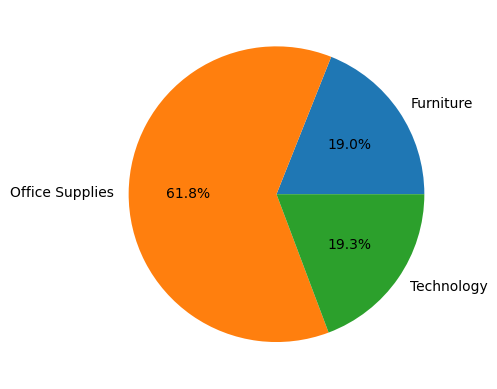

In [ ]:

plt.pie(
    dbo['Sub-Category'],
    labels = dbo.index,
    autopct = '%1.1f%%'
    );

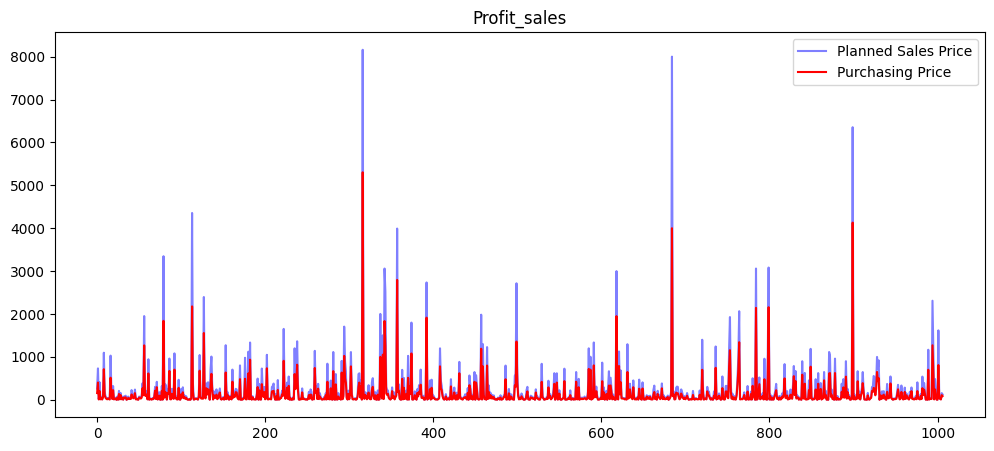

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(final_df['Planned Sales Price'],label='Planned Sales Price',c='b',alpha=0.5)
plt.plot(final_df['Purchasing Price'],label='Purchasing Price',c='r',alpha=1)
plt.title('Profit_sales')
plt.legend()

In [ ]:
final_df['Ship Mode'].value_counts()

,count
Ship Mode,
Standard Class,586
Second Class,217
First Class,185
Same Day,19


([<matplotlib.patches.Wedge at 0x7fe56d652f50>,
 [Text(-0.2800023058934443, 1.0637662848080656, 'Standard Class'),
  Text(-0.40704163877260835, -1.0219183452239762, 'Second Class'),
  Text(0.844362410844998, -0.7050192331787998, 'First Class'),
  Text(1.0980681593183668, -0.06516377437790158, 'Same Day')],
 [Text(-0.15272853048733323, 0.5802361553498538, '58.2%'),
  Text(-0.22202271205778634, -0.5574100064858051, '21.5%'),
  Text(0.4605613150063625, -0.3845559453702544, '18.4%'),
  Text(0.598946268719109, -0.03554387693340086, '1.9%')])

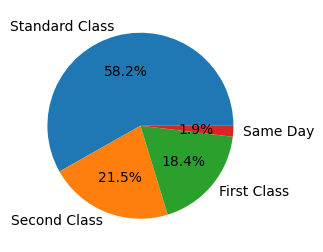

In [ ]:

plt.figure(figsize=(3, 4))
ship_mode_counts = final_df['Ship Mode'].value_counts()
plt.pie(
    ship_mode_counts,                 # Values
    labels=ship_mode_counts.index,   # Labels
    autopct='%1.1f%%'              # Rotate start
    )

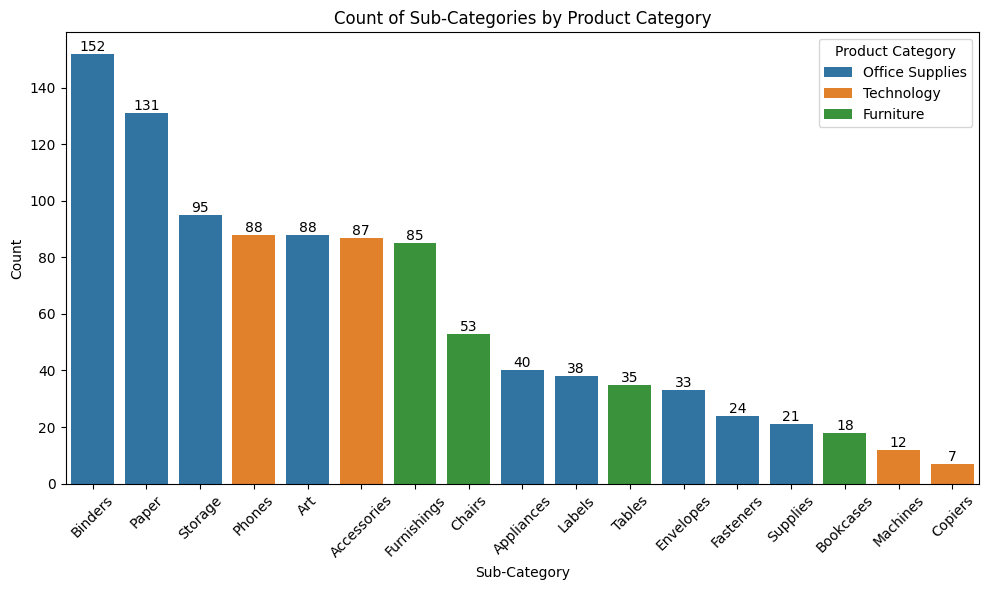

In [ ]:
grouped = final_df.groupby(['Product Category','Sub-Category']).size().reset_index(name='Count').sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=grouped, x='Sub-Category', y='Count', hue='Product Category')
plt.xticks(rotation=45)
plt.title("Count of Sub-Categories by Product Category")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [ ]:

# Count Sub-Category per Product Category
grouped = final_df.groupby(['Product Category', 'Sub-Category']).size().reset_index(name='Count')

# Create dropdown-interactive pie chart
fig = px.pie(
    grouped,
    names='Sub-Category',
    values='Count',
    color='Sub-Category',
    title='Sub-Category Distribution',
)

# Add dropdown slicer (filter by Product Category)
fig.update_layout(
    updatemenus=[{
        "buttons": [
            {
                "method": "restyle",
                "label": cat,
                "args": [
                    {
                        "labels": [grouped[grouped['Product Category'] == cat]['Sub-Category']],
                        "values": [grouped[grouped['Product Category'] == cat]['Count']],
                    }
                ],
            }
            for cat in grouped['Product Category'].unique()
        ],
        "direction": "down",
        "showactive": True,
        "x": 0.1,
        "xanchor": "left",
        "y": 1.1,
        "yanchor": "top"
    }]
)

fig.show()